# Statistiques escriptives sur les données électorales et socio-économiques

In [1]:
import pandas as pd
import numpy as np
import openpyxl
import glob
import os
import zipfile
import requests
import io
import matplotlib.pyplot as plt
import seaborn as sns
from zipfile import ZipFile
from io import BytesIO

Import des données

In [2]:
data = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\données_caracteristiques_communes.csv", index_col=0)
data['codecommune'] = data['codecommune'].astype(str).str.zfill(5)

# correction de la variable pbac
data['pbac'] = (data['pbac'] - data['psup']).clip(lower=0)

data.head()

C:\Users\yancr\AppData\Local\Temp\ipykernel_24732\184722120.py:1: DtypeWarning: Columns (0: Annee) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\données_caracteristiques_communes.csv", index_col=0)


,codecommune,Annee,pop,propf,prop014,prop1539,prop4059,prop60p,petranger,pcapi,...,pbac,psup,revmoy,vote_EG_pres,abstention_pres,vote_RN_pres,vote_EG_leg,abstention_leg,vote_RN_leg,typologie_urbaine
0,01001,1995,662,0.471756,0.268702,0.280916,0.258015,0.192366,0.016320,0.294118,...,0.044811,0.073113,12110.340,0.076056,0.201285,0.225352,NaN,NaN,NaN,Rural non périurbain
1,01001,1996,678,0.468657,0.270149,0.270149,0.265672,0.194030,0.017366,0.297521,...,0.045872,0.075688,11530.236,NaN,NaN,NaN,NaN,NaN,NaN,Rural non périurbain
2,01001,1997,695,0.467930,0.272595,0.259475,0.271137,0.196793,0.016997,0.298387,...,0.046875,0.080357,12207.807,NaN,NaN,NaN,0.098639,0.337607,0.20068,Rural non périurbain
3,01001,1998,711,0.465714,0.272857,0.250000,0.278571,0.198571,0.018006,0.305882,...,0.049892,0.082429,12892.058,NaN,NaN,NaN,NaN,NaN,NaN,Rural non périurbain
4,01001,1999,728,0.463687,0.273743,0.240223,0.284916,0.201117,0.018945,0.307692,...,0.050847,0.084746,12839.338,NaN,NaN,NaN,NaN,NaN,NaN,Rural non périurbain


## Données électorales

### Evolution du vote FN/RN aux élections présidentielles selon le type de communes (1995-2022)

In [5]:
data_pres = data[data['Annee'].isin([1995,2002,2007,2012,2017,2022])]

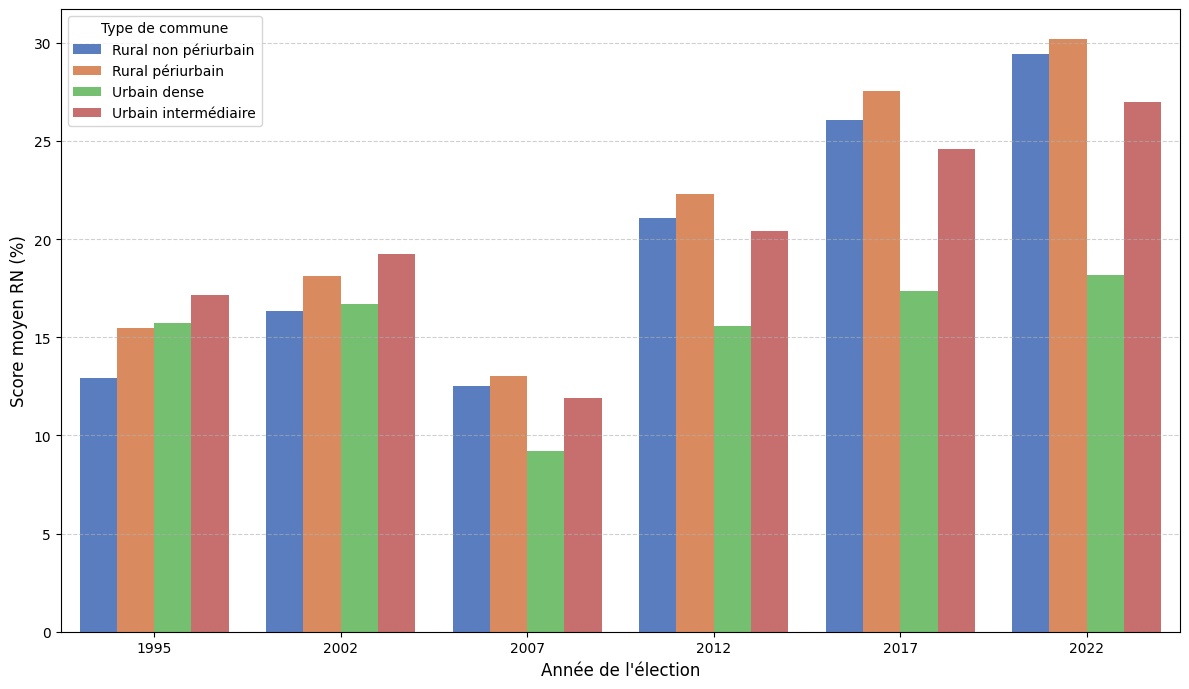

In [20]:
# 1. Préparation des données : calcul de la moyenne du score RN par année et par typologie
df_bar = data_pres.groupby(['Annee', 'typologie_urbaine'])['vote_RN_pres'].mean().reset_index()

# Conversion en pourcentages (multiplication par 100)
df_bar['vote_RN_pres'] = df_bar['vote_RN_pres'] * 100

# 2. Création du graphique en barres verticales
plt.figure(figsize=(12, 7))
sns.barplot(
    data=df_bar, 
    x='Annee', 
    y='vote_RN_pres', 
    hue='typologie_urbaine', 
    palette='muted' # Palette de couleurs distinctes
)

# 3. Personnalisation du rendu
#plt.title("Évolution du score moyen du RN par typologie de commune", fontsize=14, fontweight='bold', pad=20)
plt.ylabel("Score moyen RN (%)", fontsize=12)
plt.xlabel("Année de l'élection", fontsize=12)

# Déplacement de la légende à l'intérieur du graphique
# loc='upper left' la place en haut à gauche. Vous pouvez aussi utiliser loc='best' pour un placement automatique.
plt.legend(title="Type de commune", loc='upper left')

# Ajout d'une grille horizontale pour faciliter la lecture des scores
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Evolution du vote FN/RN aux élections législatives selon le type de communes (1997-2022)

In [8]:
data_leg = data[data['Annee'].isin([1997,2002,2007,2012,2017,2022])]

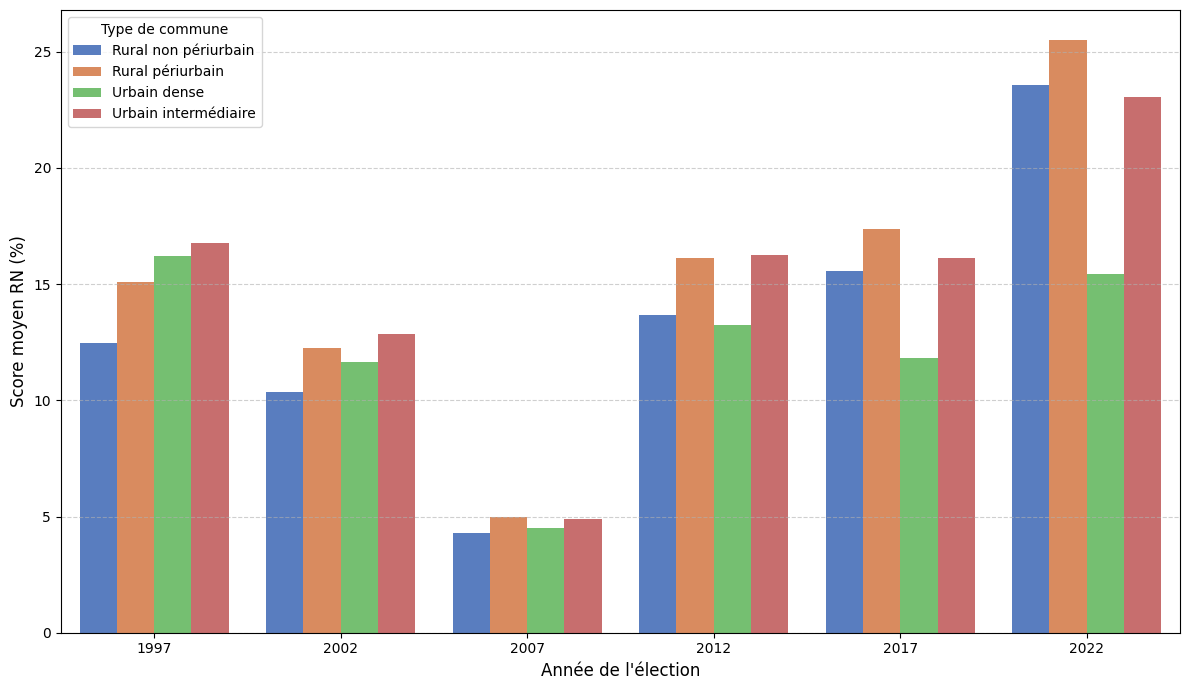

In [19]:
# 1. Préparation des données : calcul de la moyenne du score RN par année et par typologie
df_bar = data_leg.groupby(['Annee', 'typologie_urbaine'])['vote_RN_leg'].mean().reset_index()

# Conversion en pourcentages (multiplication par 100)
df_bar['vote_RN_leg'] = df_bar['vote_RN_leg'] * 100

# 2. Création du graphique en barres verticales
plt.figure(figsize=(12, 7))
sns.barplot(
    data=df_bar, 
    x='Annee', 
    y='vote_RN_leg', 
    hue='typologie_urbaine', 
    palette='muted' # Palette de couleurs distinctes
)

# 3. Personnalisation du rendu
#plt.title("Évolution du score moyen du RN par typologie de commune", fontsize=14, fontweight='bold', pad=20)
plt.ylabel("Score moyen RN (%)", fontsize=12)
plt.xlabel("Année de l'élection", fontsize=12)

# Déplacement de la légende à l'intérieur du graphique
# loc='upper left' la place en haut à gauche. Vous pouvez aussi utiliser loc='best' pour un placement automatique.
plt.legend(title="Type de commune", loc='upper left')

# Ajout d'une grille horizontale pour faciliter la lecture des scores
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Données socio-économiques

In [12]:
data_se = data[data['Annee'].isin([1995,1997,2002,2007,2012,2017,2022])]

Evolution des CSP

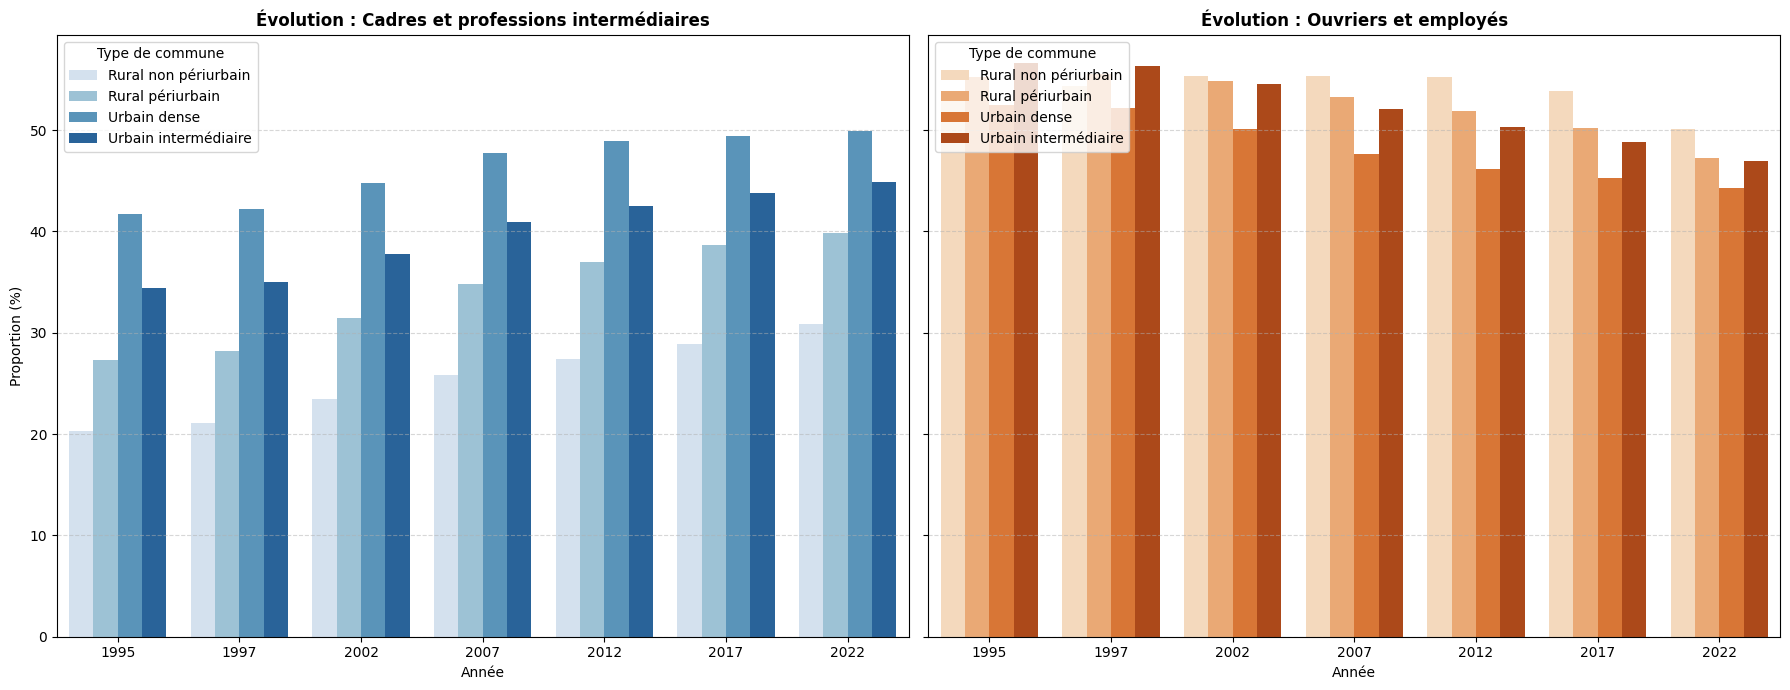

In [18]:
# 1. Préparation des données (correction du groupby avec doubles crochets)
df_bar = data_se.groupby(['Annee', 'typologie_urbaine'])[['pcapi', 'pouem']].mean().reset_index()

# Conversion en pourcentages (multiplication par 100 pour les deux colonnes)
df_bar[['pcapi', 'pouem']] = df_bar[['pcapi', 'pouem']] * 100

# 2. Création de la figure avec deux sous-graphiques côte à côte
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

# --- Graphique 1 : Cadres & Professions Intermédiaires ---
sns.barplot(
    data=df_bar, 
    x='Annee', 
    y='pcapi', 
    hue='typologie_urbaine', 
    palette='Blues', 
    ax=ax1
)
ax1.set_title("Évolution : Cadres et professions intermédiaires", fontsize=12, fontweight='bold')
ax1.set_ylabel("Proportion (%)")
ax1.set_xlabel("Année")
# Légende à l'intérieur en haut à gauche
ax1.legend(title="Type de commune", loc='upper left')
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# --- Graphique 2 : Ouvriers ---
sns.barplot(
    data=df_bar, 
    x='Annee', 
    y='pouem', 
    hue='typologie_urbaine', 
    palette='Oranges', 
    ax=ax2
)
ax2.set_title("Évolution : Ouvriers et employés", fontsize=12, fontweight='bold')
ax2.set_ylabel("") # On enlève le label car sharey=True
ax2.set_xlabel("Année")
# Légende à l'intérieur en haut à gauche
ax2.legend(title="Type de commune", loc='upper left')
ax2.grid(axis='y', linestyle='--', alpha=0.5)

#plt.suptitle("Évolution des CSP par typologie de commune", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Evolution du revenu moyen

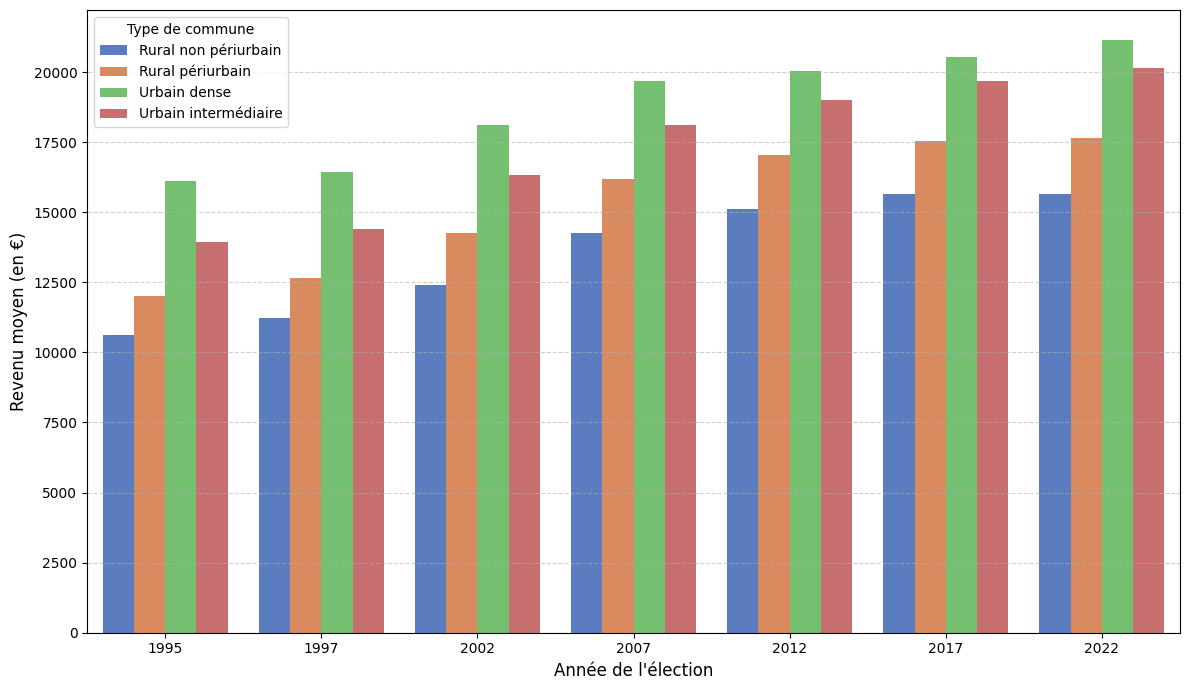

In [21]:
# 1. Préparation des données : calcul du revenu moyen par année et par typologie
# On suppose que votre colonne de catégorie s'appelle 'typologie'
df_bar = data_se.groupby(['Annee', 'typologie_urbaine'])['revmoy'].mean().reset_index()

# 2. Création du graphique en barres verticales
plt.figure(figsize=(12, 7))
sns.barplot(
    data=df_bar, 
    x='Annee', 
    y='revmoy', 
    hue='typologie_urbaine', 
    palette='muted' # Palette de couleurs distinctes
)

# 3. Personnalisation du rendu
#plt.title("Évolution du revenu moyen par typologie de commune", fontsize=14, fontweight='bold', pad=20)
plt.ylabel("Revenu moyen (en €)", fontsize=12)
plt.xlabel("Année de l'élection", fontsize=12)
plt.legend(title="Type de commune", loc='upper left')

# Ajout d'une grille horizontale pour faciliter la lecture des scores
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()